# Exercise 4

## Imports and Configuration
We load libraries for hyperspectral processing, STAC discovery, and statistical analysis.

In [40]:
# !uv pip install rasterio spectral pystac_client planetary_computer

In [69]:
import os
from datetime import datetime, timedelta
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from skimage.transform import resize
from rasterio.warp import transform, transform_bounds
from rasterio.windows import from_bounds, Window
import spectral.io.envi as envi
from pystac_client import Client
from pyproj import Transformer
import planetary_computer
from scipy.stats import linregress

import warnings
warnings.filterwarnings('ignore')

ACQUISITION_DATE = '2025-06-17'

print("Libraries imported successfully.")


Libraries imported successfully.


Solve windows problems
![lol](https://i.redd.it/im-tired-boss-the-green-mile-v0-5n6l9b34iecg1.jpg?width=1920&format=pjpg&auto=webp&s=40328510925c2b7573b90bf1e1a923d77ecba0cd)

In [42]:
# !pip uninstall rasterio pyproj -y
# !pip install rasterio pyproj

In [43]:
# os.environ["PROJ_LIB"] = r"E:\github_repos\eolabs\.venv\Lib\site-packages\rasterio\proj_data"
# del os.environ["PROJ_LIB"]

## Loading Airborne Data

In [44]:
LAB_5_DIR = Path().cwd() / "lab_5"
BASE_DIR = LAB_5_DIR / "data" / "you-shall-not-pass" / "Obrazy lotnicze"
print(BASE_DIR)
hdr_path = BASE_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.hdr'
bsq_path = BASE_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.bsq'

E:\github_repos\eolabs\lab_5\data\you-shall-not-pass\Obrazy lotnicze


In [113]:
if hdr_path.exists():
    img = envi.open(hdr_path)
    print(f"Opened airborne cube: {hdr_path.name}")
    print(f"Shape: {img.shape}")
    
    # Since the cubes are large and memory overload is totally possible
    # only a subset is loaded
    cy, cx = img.nrows // 2, img.ncols // 2
    row_range = cy - 500, cy + 500
    col_range = cx - 500, cx + 500
    airborne_cube = img.read_subregion(row_range, col_range)
    
    # Get wavelengths
    wavelengths = np.array([float(x) for x in img.metadata['wavelength']])
    print(f"Loaded subset shape: {airborne_cube.shape}")
else:
    print("Airborne data not found")

Opened airborne cube: 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
Shape: (4300, 2001, 456)
Loaded subset shape: (1000, 1000, 456)


Extract bounding box for sentinel 2 data - step learnt by a whole lot of problems

In [114]:
with rasterio.open(bsq_path) as src:
    air_win = Window(
        col_range[0],                # col_off
        row_range[0],                # row_off
        col_range[1] - col_range[0],        # width
        row_range[1] - row_range[0]         # height
    )

    air_left, air_bottom, air_right, air_top = src.window_bounds(air_win)

    # se correct EPSG
    lons, lats = transform(
        src.crs,
        "EPSG:4326",
        [air_left, air_right],
        [air_bottom, air_top]
    )

    subset_bbox = [lons[0], lats[0], lons[1], lats[1]]

print("subset_bbox:", subset_bbox)

subset_bbox: [18.143792642483536, 50.338342423901075, 18.157870125172504, 50.347314786169]


## Description of Methods

Different land cover types (water, forest, green areas) are loaded as reference spectra for SAM.

In [115]:
sig_dir = LAB_5_DIR / "spectral_signatures"
sig_files = list(sig_dir.glob('*.csv'))

spectra = {}
for f in sig_files:
    class_name = f.stem.rstrip('1234567890')
    df = pd.read_csv(f)
    if class_name not in spectra: spectra[class_name] = []
    spectra[class_name].append(df['value'].values)

# Calculate mean spectra for each class
reference_spectra = {k: np.nanmean(v, axis=0) for k, v in spectra.items()}
print(f"Reference classes: {list(reference_spectra.keys())}")

Reference classes: ['building', 'clean_water', 'dirty_water', 'forest', 'green', 'water']


#### Helper functions

In [116]:
SCALE_FACTOR = 10000.0
IGNORE_VALUE = 15000.0


def find_band(target_nm, wavelengths):
    """Return the 0-based band index closest to target_nm."""
    return int(np.argmin(np.abs(wavelengths - target_nm)))


def read_reflectance(img, band_idx, subregion=None):
    """Read a band; apply mask & scale to fractional reflectance."""
    if subregion:
        data = img.read_subregion(subregion[0], subregion[1], bands=[band_idx]).squeeze().astype(np.float32)
    else:
        data = img.read_bands([band_idx]).squeeze().astype(np.float32)
    data = np.where((data >= IGNORE_VALUE) | (data < 0), np.nan, data)
    return data / SCALE_FACTOR

## Spectral Angle Mapper (SAM)

SAM calculates the spectral similarity between a reference spectrum and each pixel by computing the angle between them in a multidimensional spectral space. 

Smaller angles indicate higher similarity.

In this case SAM can distinguish between different types of water, which can show the contamination

It's calculated, because while the same pixel can appear brighter/darker based on conditions, but it will not change the spectral signature significantly, which can help identify different materials

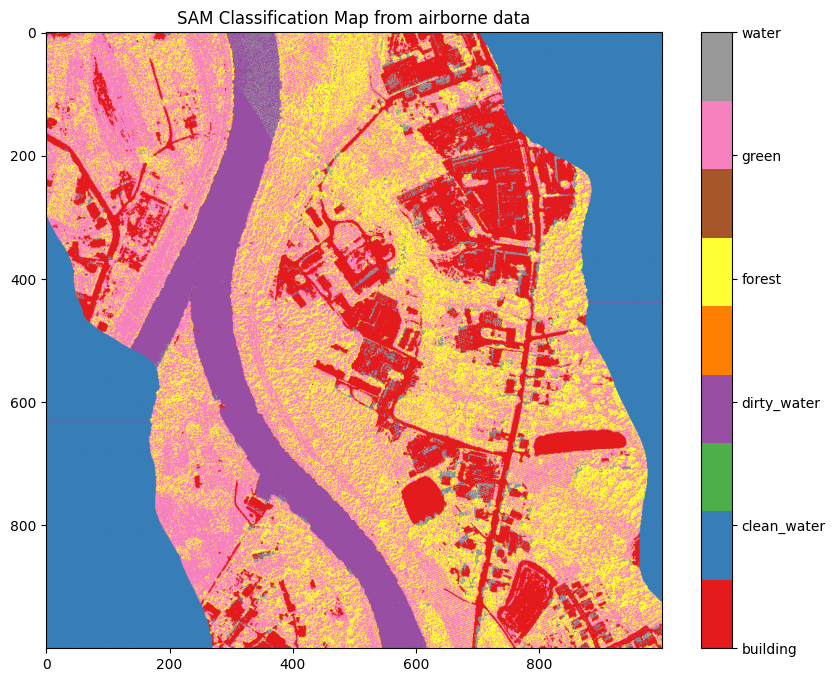

In [117]:
def compute_sam(hypercube, ref_spectrum):
    # ref_spectrum might need interpolation if band counts differ
    if len(ref_spectrum) != hypercube.shape[2]:
        ref_spectrum = np.interp(
            np.linspace(0, 1, hypercube.shape[2]), 
            np.linspace(0, 1, len(ref_spectrum)), 
            ref_spectrum
        )
    
    dot_product = np.sum(hypercube * ref_spectrum, axis=2)
    norm_cube = np.sqrt(np.sum(hypercube**2, axis=2))
    norm_ref = np.sqrt(np.sum(ref_spectrum**2))
    cos_theta = dot_product / (norm_cube * norm_ref + 1e-8)
    # clip values to arcos range to avoid numerical issues
    return np.arccos(np.clip(cos_theta, -1.0, 1.0))

# each class is applied the SAM
sam_maps = {k: compute_sam(airborne_cube, ref) for k, ref in reference_spectra.items()}

# minimal angle is used to classify pixels
class_names = list(sam_maps.keys())
stacked_angles = np.stack([sam_maps[k] for k in class_names], axis=-1)
classification = np.argmin(stacked_angles, axis=-1)

# plot the SAM classification map
plt.figure(figsize=(10, 8))
im = plt.imshow(classification, cmap='Set1')
cbar = plt.colorbar(im, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
plt.title('SAM Classification Map from airborne data')
plt.show()

for larger area:

![larger area](data\images\chart-larger.png)

#### Map of angles

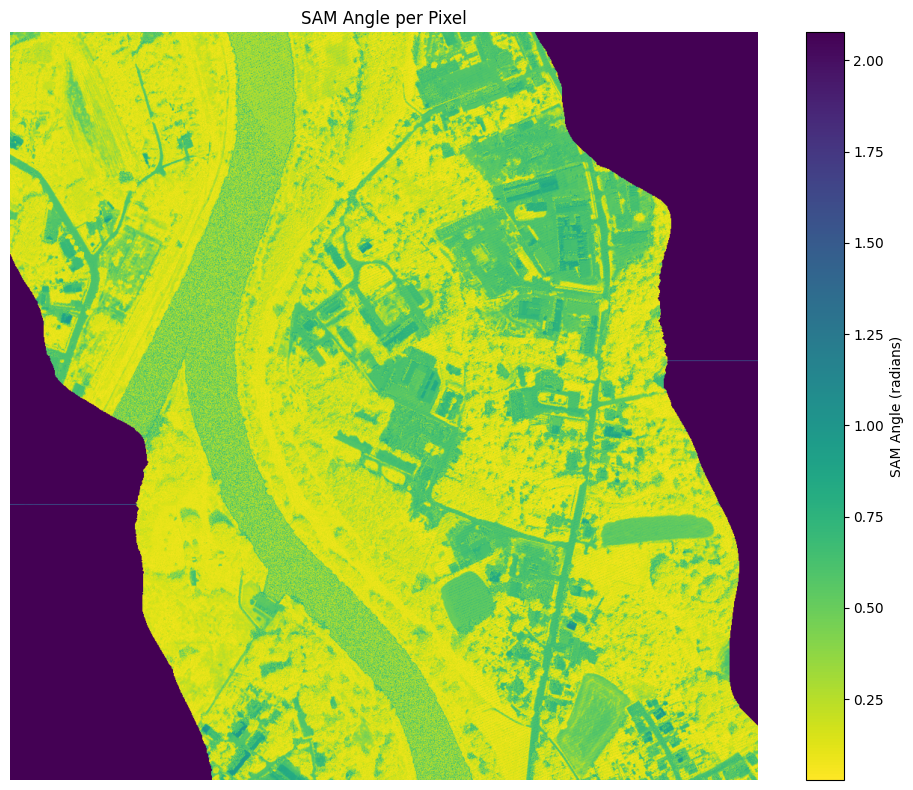

In [165]:
min_angles = np.min(stacked_angles, axis=-1)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(min_angles, cmap='viridis_r')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('SAM Angle (radians)')
ax.set_title('SAM Angle per Pixel')
ax.axis('off')
plt.tight_layout()
plt.show()

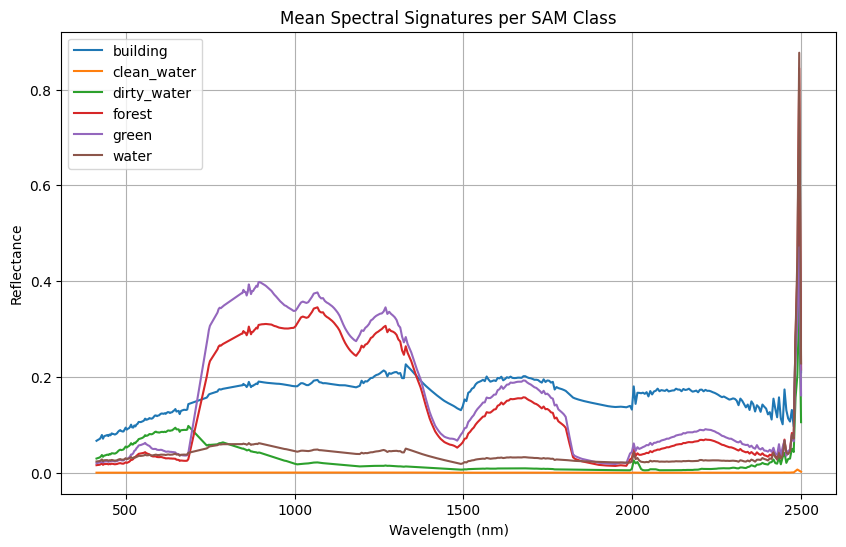

In [118]:
import numpy as np
import matplotlib.pyplot as plt

class_names = list(sam_maps.keys())

plt.figure(figsize=(10, 6))

for i, name in enumerate(class_names):
    mask = classification == i

    # mean spectrum for this class
    mean_spec = np.nanmean(airborne_cube[mask], axis=0)

    plt.plot(wavelengths, mean_spec, label=name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Mean Spectral Signatures per SAM Class")
plt.legend()
plt.grid(True)
plt.show()

As it can be seen there are the multiple classes visible, the colorbar is a bit off (the intuition is not your friend here, but it actually got the classses right)

More classes should have been defined for instance fields and buildings, as they might blend and be considered water, which is a case here

In my second attempt I have added buildings, but they seem to be much more diverse for instance in the aspect of color variety 

In third attempt I have added water, it's incredibly interesting to see that clean water has near zero reflectance!

adding buildings has clearily made the analysis on land harder, however it has shown a whole bunch of small particles/clusters in the river - it might be the particles that kill fish!

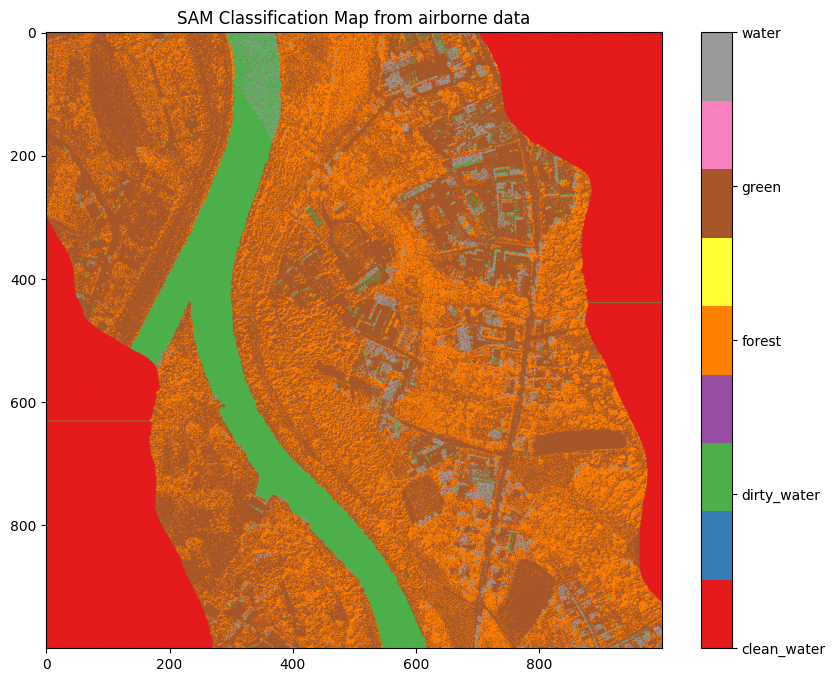

In [119]:
# try again without buildings
reference_spectra.pop("building")

sam_maps = {k: compute_sam(airborne_cube, ref) for k, ref in reference_spectra.items()}
class_names = list(sam_maps.keys())
stacked_angles = np.stack([sam_maps[k] for k in class_names], axis=-1)
classification = np.argmin(stacked_angles, axis=-1)

# plot the SAM classification map
plt.figure(figsize=(10, 8))
im = plt.imshow(classification, cmap='Set1')
cbar = plt.colorbar(im, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)
plt.title('SAM Classification Map from airborne data')
plt.show()

As it can be seen this part of image contains mostly dirty water, however looking at the top of the frame one can see there's actually a bit of clean water "particles", showing the water is not fully contaminated

## Fetch Sentinel-2 Data for aquisition date

**2025-07-17**

SSL workaround, seems that I need it every time I use pystack on my Windows machine

In [50]:
import certifi
import os

os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()

In [120]:
target_date = datetime.strptime(ACQUISITION_DATE, "%Y-%m-%d")
start_date = (target_date - timedelta(days=7)).strftime("%Y-%m-%d")
end_date = (target_date + timedelta(days=7)).strftime("%Y-%m-%d")

catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1", 
    modifier=planetary_computer.sign_inplace
)

search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=subset_bbox,
    datetime=f"{start_date}/{end_date}",
    query={"eo:cloud_cover": {"lt": 20}}
)

items = list(search.items())
if items:
    best_item = items[0]
    print(f"Found Sentinel-2 item: {best_item.id}")
    
    # Access bands for RGB + NIR
    assets = best_item.assets

    print("loaded bands")
else:
    print("couldn't load bands")

Found Sentinel-2 item: S2C_MSIL2A_20250615T095051_R079_T33UYR_20250615T122401
loaded bands


Again two days off

#### Display Sentinel 2 images

to confirm the area is correct...

In [121]:
S2_BANDS = ['B02', 'B03', 'B04', 'B05', 'B08', 'SCL']
data = {}

with rasterio.open(assets['B04'].href) as src:
    transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
    minx, miny, maxx, maxy = transform_bounds(
        "EPSG:4326",
        src.crs,
        *subset_bbox
    )
    s2_win = src.window(minx, miny, maxx, maxy)
    s2_prof = {'crs': src.crs, 'transform': src.window_transform(s2_win), 
               'width': int(s2_win.width), 'height': int(s2_win.height)}

for b in S2_BANDS:
    with rasterio.open(assets[b].href) as src:
        data[b] = src.read(1, window=s2_win, out_shape=(s2_prof['height'], s2_prof['width']), 
                              resampling=rasterio.enums.Resampling.bilinear).astype(float)
        if b != 'SCL':
            data[b] = np.where(data[b] == 0, np.nan, data[b] / 10000.0)

power function for stretching values (useful for plotting)

In [131]:
def stretch(img, p_low=2, p_high=98):
    lo, hi = np.percentile(img, (p_low, p_high))
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)


def plot_index(ax, data, mask, title, cmap='RdYlGn', vmin=None, vmax=None, clabel=''):
    display = np.where(mask, data, np.nan)
    if vmin is None: vmin = np.nanpercentile(display, 2)
    if vmax is None: vmax = np.nanpercentile(display, 98)
    bg = np.ones((*mask.shape, 3)) * 0.85
    ax.imshow(bg)
    im = ax.imshow(display, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label=clabel)
    ax.set_title(title)
    ax.axis('off')

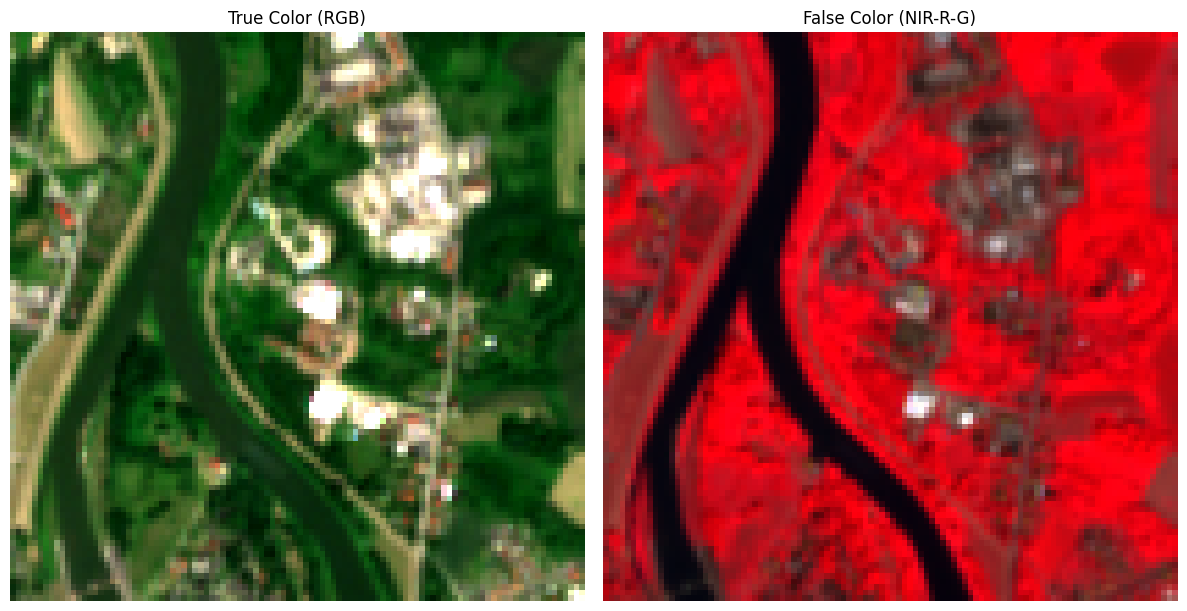

In [124]:
# create images out of the bands
rgb = np.dstack([data["B04"], data["B03"], data["B02"]])
false_color = np.dstack([data["B08"], data["B04"], data["B03"]])

rgb_stretch = stretch(rgb)
fc_stretch = stretch(false_color)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(rgb_stretch)
axes[0].set_title("True Color (RGB)")
axes[0].axis("off")

axes[1].imshow(fc_stretch)
axes[1].set_title("False Color (NIR-R-G)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

You can clearly see the difference between 10m vs 1m resolution

## Calibrate Sentinel-2 using Airborne Data

I'll use linear regression to calibrate the sentinel 2 data, as both EO methods measure the same area and same properities of water so we could potentially use airborne model as a baseline for data with lower resolution

##### 1. Get bands so that we can compare indices from previous tasks, ultimately that's the goal of analyses so the model HAS to take that into consideration

###### Sentinel 2 indices

that's really small (H6)

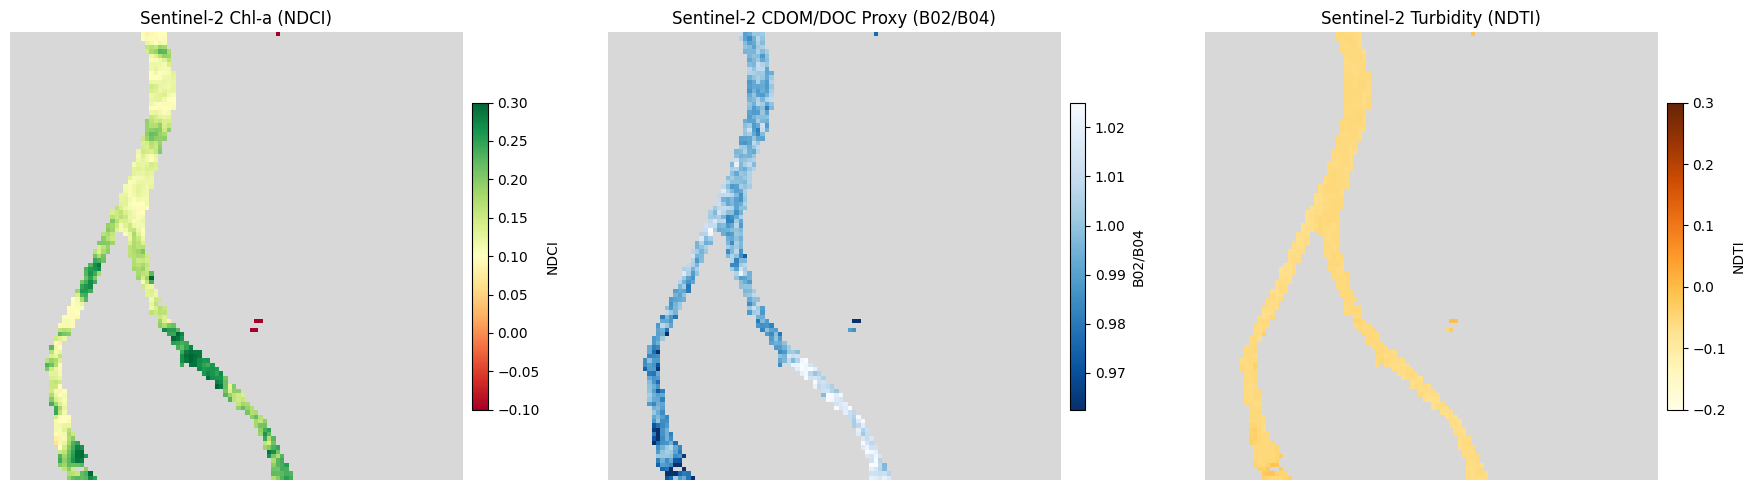

In [141]:
B02 = data['B02']
B03 = data['B03']
B04 = data['B04']
B05 = data['B05']
B08 = data['B08']
SCL = data['SCL']

# Sentinel-2 Water Mask
ndwi_s2 = (B03 - B08) / (B03 + B08 + 1e-9)
s2_water_mask = (SCL == 6) | (ndwi_s2 > 0)
s2_water_mask &= np.isfinite(B04)

chla_s2 = (B05 - B04) / (B05 + B04 + 1e-9)
doc_s2 = B02 / (B04 + 1e-9)
turb_s2 = (B04 - B03) / (B04 + B03 + 1e-9)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_index(axes[0], chla_s2, s2_water_mask, "Sentinel-2 Chl-a (NDCI)", 'RdYlGn', -0.1, 0.3, 'NDCI')
plot_index(axes[1], doc_s2, s2_water_mask, "Sentinel-2 CDOM/DOC Proxy (B02/B04)", 'Blues_r', clabel='B02/B04')
plot_index(axes[2], turb_s2, s2_water_mask, "Sentinel-2 Turbidity (NDTI)", 'YlOrBr', -0.2, 0.3, 'NDTI')
plt.tight_layout()
plt.show()

###### Airborne - band extraction + indices

In [142]:
R443 = read_reflectance(img, find_band(443, wavelengths), (row_range, col_range))
R560 = read_reflectance(img, find_band(560, wavelengths), (row_range, col_range))
R665 = read_reflectance(img, find_band(665, wavelengths), (row_range, col_range))
R709 = read_reflectance(img, find_band(709, wavelengths), (row_range, col_range))


chla_air = (R709 - R665) / (R709 + R665 + 1e-9)
doc_air = R443 / (R665 + 1e-9)
turb_air = (R665 - R560) / (R665 + R560 + 1e-9)

##### 2. we need matching sizes of images so that they can be used in the same calculation/modelling 

In [ ]:
air_to_s2_ratio = airborne_cube.shape[0] // data["B02"].shape[0]

print(f"Airborne shape: {airborne_cube.shape[:2]}")
print(f"Sentinel-2 shape: {data['B02'].shape}")
print(f"Aggregation ratio: {air_to_s2_ratio}")

def aggregate_to_s2_resolution(data_air, ratio):
    """Aggregate high-res airborne data to Sentinel-2 resolution using spatial averaging"""
    h_air, w_air = data_air.shape[:2]
    h_s2 = h_air // ratio
    w_s2 = w_air // ratio
    
    # Reshape and take mean along aggregation axes
    reshaped = data_air[:h_s2*ratio, :w_s2*ratio].reshape(
        h_s2, ratio, w_s2, ratio
    )
    # each block is an average of airborne image
    aggregated = np.nanmean(reshaped, axis=(1, 3))
    
    return aggregated

# Aggregate the bands
R443_agg = aggregate_to_s2_resolution(R443, air_to_s2_ratio)
R560_agg = aggregate_to_s2_resolution(R560, air_to_s2_ratio)
R665_agg = aggregate_to_s2_resolution(R665, air_to_s2_ratio)
R709_agg = aggregate_to_s2_resolution(R709, air_to_s2_ratio)

# indices for the aggregated data
chla_air_agg = (R709_agg - R665_agg) / (R709_agg + R665_agg + 1e-9)
doc_air_agg = R443_agg / (R665_agg + 1e-9)
turb_air_agg = (R665_agg - R560_agg) / (R665_agg + R560_agg + 1e-9)

print(f"Aggregated index shapes: {chla_air_agg.shape}")


Airborne shape: (1000, 1000)
Sentinel-2 shape: (103, 104)
Aggregation ratio: 9
Aggregated index shapes: (111, 111)


##### 3. create a function that will create a model for the data
please note that we only use elements that are finite, infinity is of no use here :D

In [162]:
def fit_calibration(x_air, x_s2, water_mask=None):
    if water_mask is not None:
        mask = water_mask & np.isfinite(x_air) & np.isfinite(x_s2)
    else:
        mask = np.isfinite(x_air) & np.isfinite(x_s2)

    X = x_s2[mask].reshape(-1, 1)
    y = x_air[mask]
    
    n_samples = np.sum(mask)
    print(f"  Training samples: {n_samples}")

    # airborne data is the target!
    model = LinearRegression()
    model.fit(X, y)
    
    # Calculate training metrics
    y_pred = model.predict(X)
    rmse = np.sqrt(np.mean((y - y_pred) ** 2))
    r2 = model.score(X, y)
    print(f"RMSE: {rmse:.4f}, R^2: {r2:.4f}")

    return model


##### 4. create models and predict new values

In [163]:
# Ensure shapes match for calibration
h_agg, w_agg = chla_air_agg.shape
h_s2, w_s2 = chla_s2.shape
# Crop all airborne and S2 arrays to the minimum overlapping shape
h = min(h_agg, h_s2)
w = min(w_agg, w_s2)

chla_air_agg_crop = chla_air_agg[:h, :w]
doc_air_agg_crop = doc_air_agg[:h, :w]
turb_air_agg_crop = turb_air_agg[:h, :w]

chla_s2_crop = chla_s2[:h, :w]
doc_s2_crop = doc_s2[:h, :w]
turb_s2_crop = turb_s2[:h, :w]
s2_water_mask_crop = s2_water_mask[:h, :w]

print("Fitting Chl-a calibration...")
model_chla = fit_calibration(chla_air_agg_crop, chla_s2_crop, s2_water_mask_crop)

print("\nFitting DOC calibration...")
model_doc  = fit_calibration(doc_air_agg_crop, doc_s2_crop, s2_water_mask_crop)

print("\nFitting Turbidity calibration...")
model_turb = fit_calibration(turb_air_agg_crop, turb_s2_crop, s2_water_mask_crop)

# Apply calibration to full Sentinel-2 data
chla_s2_cal = model_chla.predict(chla_s2.reshape(-1, 1)).reshape(chla_s2.shape)
doc_s2_cal  = model_doc.predict(doc_s2.reshape(-1, 1)).reshape(doc_s2.shape)
turb_s2_cal = model_turb.predict(turb_s2.reshape(-1, 1)).reshape(turb_s2.shape)

print("\nCalibration complete!")


Fitting Chl-a calibration...
  Training samples: 551
RMSE: 0.2241, R^2: 0.0066

Fitting DOC calibration...
  Training samples: 551
RMSE: 0.0873, R^2: 0.0108

Fitting Turbidity calibration...
  Training samples: 551
RMSE: 0.1129, R^2: 0.0042

Calibration complete!


##### 5. show the data along its calibrated version

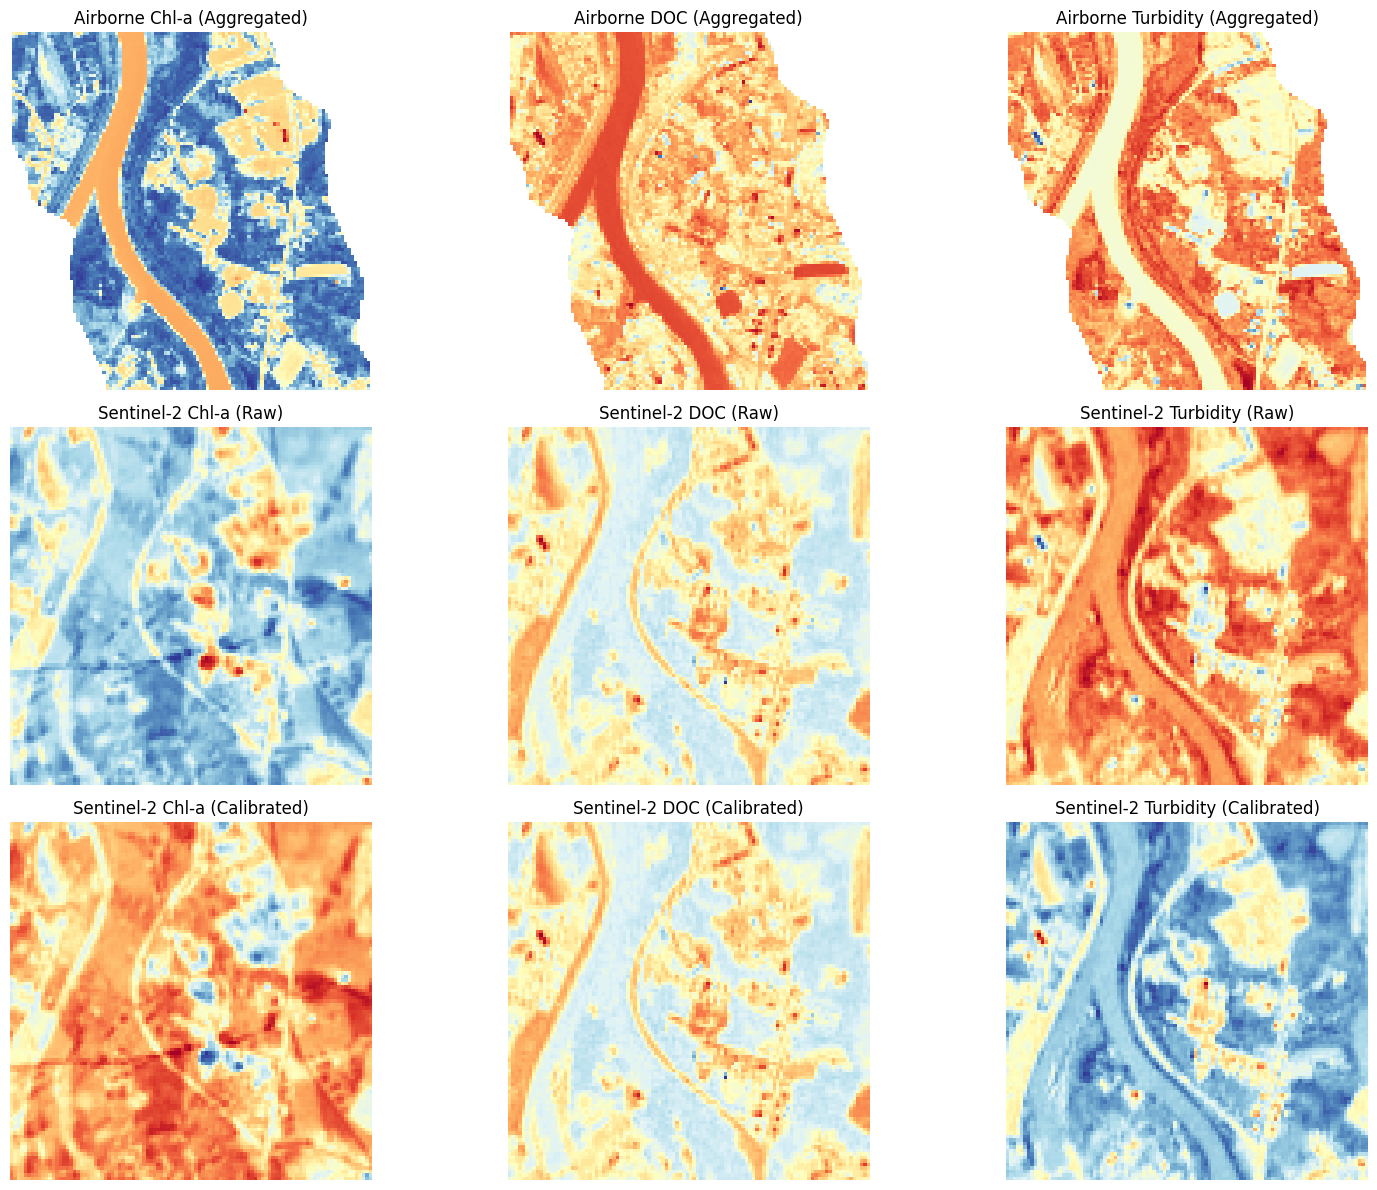

In [164]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

# Row 0: Aggregated airborne data
axes[0,0].imshow(chla_air_agg, cmap="RdYlBu")
axes[0,0].set_title("Airborne Chl-a (Aggregated)")

axes[0,1].imshow(doc_air_agg, cmap="RdYlBu")
axes[0,1].set_title("Airborne DOC (Aggregated)")

axes[0,2].imshow(turb_air_agg, cmap="RdYlBu")
axes[0,2].set_title("Airborne Turbidity (Aggregated)")

# Row 1: Sentinel-2 raw
axes[1,0].imshow(chla_s2, cmap="RdYlBu")
axes[1,0].set_title("Sentinel-2 Chl-a (Raw)")

axes[1,1].imshow(doc_s2, cmap="RdYlBu")
axes[1,1].set_title("Sentinel-2 DOC (Raw)")

axes[1,2].imshow(turb_s2, cmap="RdYlBu")
axes[1,2].set_title("Sentinel-2 Turbidity (Raw)")

# Row 2: Sentinel-2 calibrated
axes[2,0].imshow(chla_s2_cal, cmap="RdYlBu")
axes[2,0].set_title("Sentinel-2 Chl-a (Calibrated)")

axes[2,1].imshow(doc_s2_cal, cmap="RdYlBu")
axes[2,1].set_title("Sentinel-2 DOC (Calibrated)")

axes[2,2].imshow(turb_s2_cal, cmap="RdYlBu")
axes[2,2].set_title("Sentinel-2 Turbidity (Calibrated)")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()


#### Analysis/Comparison
It's worth noting that at time of writing the initial comment there's a difference in indices for airborne and sentinel 2 data, which I will get on top of (soon). However what can be seen is the influence of calibration on indices, first and foremost for DOC the change is clearily visible, the colors have shifted slightly and resemble airborne indices more which shows that the linear regression actually "translates the values" from one image to the other - that's expected and wanted in this case.

For ChI-a it's mroe similiar in terms of colors, but a bit sharper in the calibrated version, which shows that the values are somewhat interpolated to resemble the airborne data, for "calibrating" spatial resolution it might actually visually improve the quality, I'll look at values and differences next to see what the calibration has "really" done.

In [ ]:
def improvement_map(air_agg, raw_s2, cal_s2, water_mask=None):
    """
    Calculate improvement from calibration as: error_raw - error_calibrated
    """
    if water_mask is not None:
        mask = water_mask & np.isfinite(air_agg) & np.isfinite(raw_s2) & np.isfinite(cal_s2)
    else:
        mask = np.isfinite(air_agg) & np.isfinite(raw_s2) & np.isfinite(cal_s2)

    err_raw = np.abs(air_agg - raw_s2)
    err_cal = np.abs(air_agg - cal_s2)

    # Improvement: how much error reduced (positive = better)
    out = np.zeros_like(air_agg)
    out[:] = np.nan
    
    out[mask] = err_raw[mask] - err_cal[mask]
    
    return out, mask


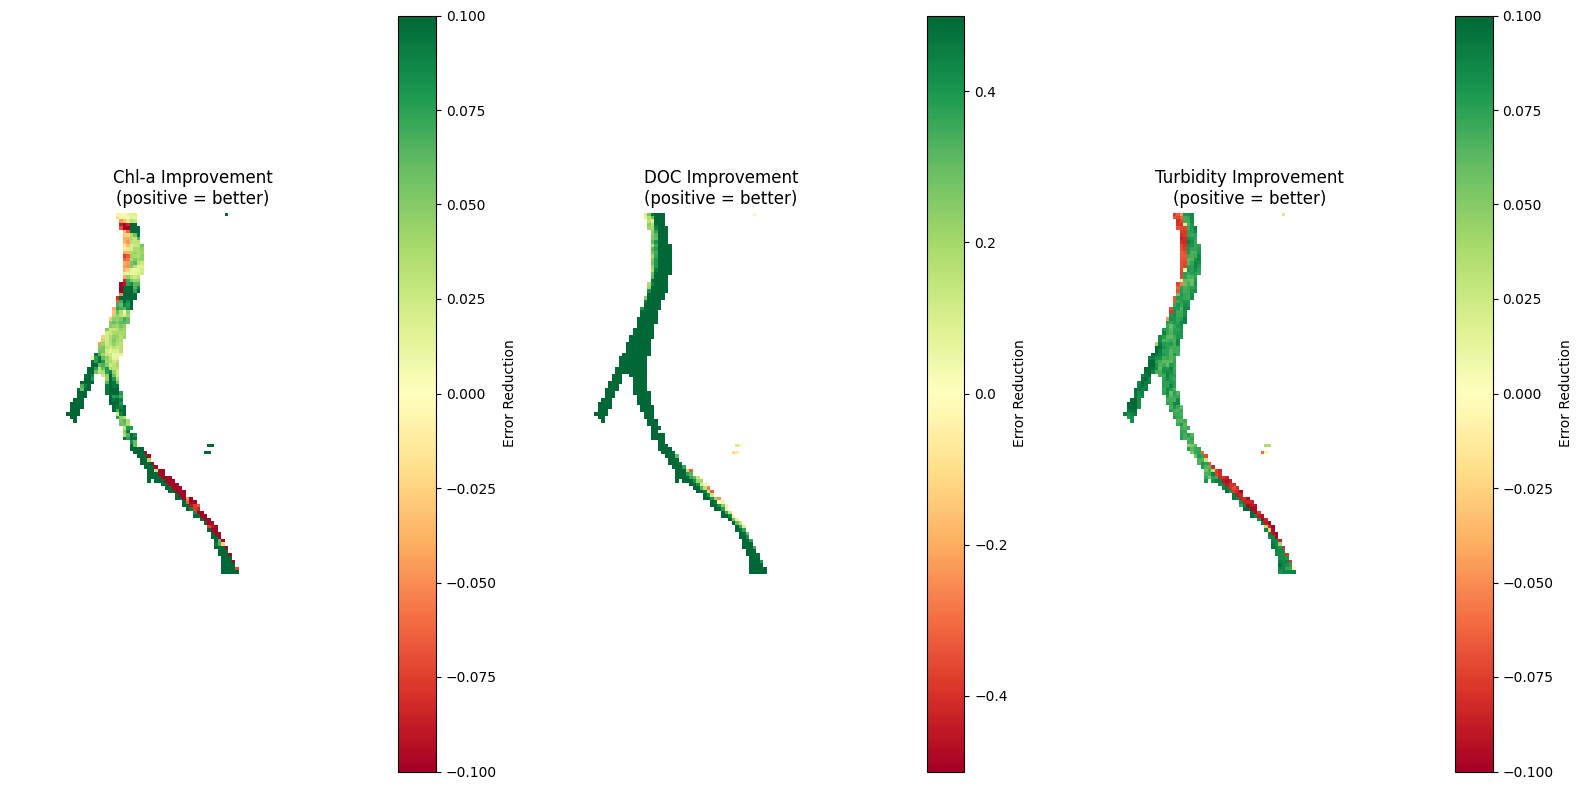

Improvement Statistics (on water pixels only):
Chl-a:    mean improvement = 0.0594
DOC:      mean improvement = 0.4976
Turbidity: mean improvement = 0.0478


In [155]:
# Use cropped arrays for improvement analysis
chla_imp, chla_mask = improvement_map(chla_air_agg_crop, chla_s2_crop, chla_s2_cal[:h, :w], s2_water_mask_crop)
doc_imp, doc_mask   = improvement_map(doc_air_agg_crop, doc_s2_crop, doc_s2_cal[:h, :w], s2_water_mask_crop)
turb_imp, turb_mask = improvement_map(turb_air_agg_crop, turb_s2_crop, turb_s2_cal[:h, :w], s2_water_mask_crop)

fig, axes = plt.subplots(1, 3, figsize=(16, 8))

im0 = axes[0].imshow(chla_imp, cmap="RdYlGn", vmin=-0.1, vmax=0.1)
axes[0].set_title("Chl-a Improvement\n(positive = better)")
plt.colorbar(im0, ax=axes[0], label='Error Reduction')

im1 = axes[1].imshow(doc_imp, cmap="RdYlGn", vmin=-0.5, vmax=0.5)
axes[1].set_title("DOC Improvement\n(positive = better)")
plt.colorbar(im1, ax=axes[1], label='Error Reduction')

im2 = axes[2].imshow(turb_imp, cmap="RdYlGn", vmin=-0.1, vmax=0.1)
axes[2].set_title("Turbidity Improvement\n(positive = better)")
plt.colorbar(im2, ax=axes[2], label='Error Reduction')

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Print improvement statistics
print("Improvement Statistics (on water pixels only):")
print(f"Chl-a:    mean improvement = {np.nanmean(chla_imp[chla_mask]):.4f}")
print(f"DOC:      mean improvement = {np.nanmean(doc_imp[doc_mask]):.4f}")
print(f"Turbidity: mean improvement = {np.nanmean(turb_imp[turb_mask]):.4f}")


Positive is considered an improvement, because it's closer to the airborne data, if it's negative it actually moved away from the high spatial resolution image and therefore the error increases. For DOC the change is massive up to 0.5 mean improvement for the water pixels in comparison to previous values

## Detailed Calibration Validation

Compute error metrics to assess calibration quality. Positive improvement means calibration brought S2 values closer to airborne reference.



Chl-a:
  Raw S2 MAE:        0.2335
  Calibrated S2 MAE: 0.1740
  MAE Improvement:   0.0594 (79.9% pixels improved)

DOC:
  Raw S2 MAE:        0.5589
  Calibrated S2 MAE: 0.0612
  MAE Improvement:   0.4976 (97.6% pixels improved)

Turbidity:
  Raw S2 MAE:        0.1329
  Calibrated S2 MAE: 0.0852
  MAE Improvement:   0.0478 (80.6% pixels improved)


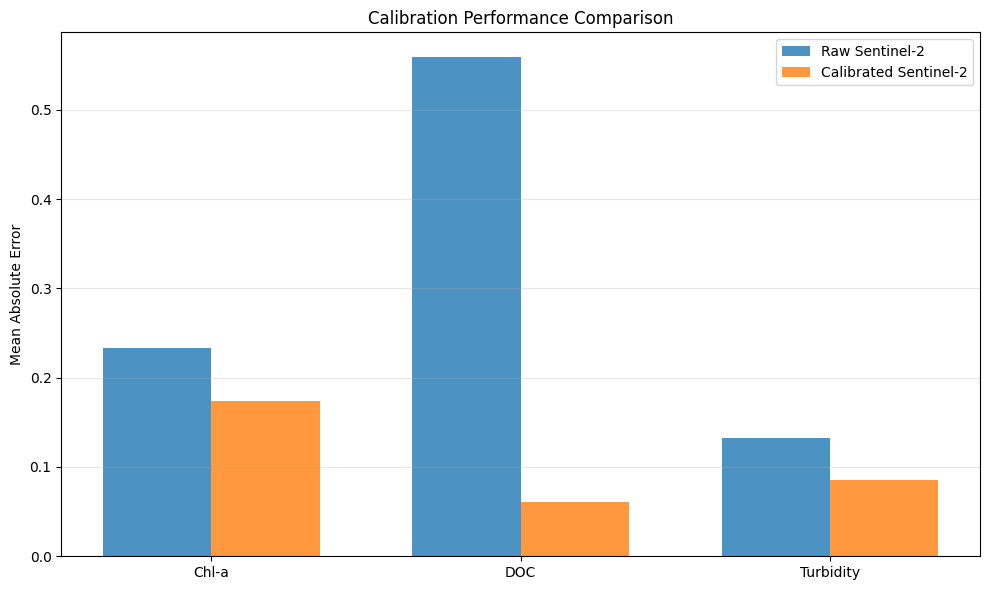

In [ ]:
def compute_error_stats(air_agg, raw_s2, cal_s2, water_mask=None, title=""):
    """Compute detailed error statistics"""
    # Use cropped arrays for error stats
    h = min(air_agg.shape[0], raw_s2.shape[0], cal_s2.shape[0], water_mask.shape[0])
    w = min(air_agg.shape[1], raw_s2.shape[1], cal_s2.shape[1], water_mask.shape[1])
    air_agg = air_agg[:h, :w]
    raw_s2 = raw_s2[:h, :w]
    cal_s2 = cal_s2[:h, :w]
    if water_mask is not None:
        water_mask = water_mask[:h, :w]
        mask = water_mask & np.isfinite(air_agg) & np.isfinite(raw_s2) & np.isfinite(cal_s2)
    else:
        mask = np.isfinite(air_agg) & np.isfinite(raw_s2) & np.isfinite(cal_s2)
    
    err_raw = np.abs(air_agg[mask] - raw_s2[mask])
    err_cal = np.abs(air_agg[mask] - cal_s2[mask])
    
    improvement = err_raw - err_cal
    percent_improved = np.sum(improvement > 0) / len(improvement) * 100
    
    print(f"\n{title}:")
    print(f"  Raw S2 MAE:        {np.mean(err_raw):.4f}")
    print(f"  Calibrated S2 MAE: {np.mean(err_cal):.4f}")
    print(f"  MAE Improvement:   {np.mean(err_raw) - np.mean(err_cal):.4f} ({percent_improved:.1f}% pixels improved)")
    
    return np.mean(err_raw), np.mean(err_cal)

mae_chla_raw, mae_chla_cal = compute_error_stats(chla_air_agg_crop, chla_s2_crop, chla_s2_cal[:h, :w], s2_water_mask_crop, "Chl-a")
mae_doc_raw, mae_doc_cal = compute_error_stats(doc_air_agg_crop, doc_s2_crop, doc_s2_cal[:h, :w], s2_water_mask_crop, "DOC")
mae_turb_raw, mae_turb_cal = compute_error_stats(turb_air_agg_crop, turb_s2_crop, turb_s2_cal[:h, :w], s2_water_mask_crop, "Turbidity")

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3)
width = 0.35

raw_maes = [mae_chla_raw, mae_doc_raw, mae_turb_raw]
cal_maes = [mae_chla_cal, mae_doc_cal, mae_turb_cal]

ax.bar(x - width/2, raw_maes, width, label='Raw Sentinel-2', alpha=0.8)
ax.bar(x + width/2, cal_maes, width, label='Calibrated Sentinel-2', alpha=0.8)

ax.set_ylabel('Mean Absolute Error')
ax.set_title('Calibration Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(['Chl-a', 'DOC', 'Turbidity'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


It can be seen that although the calibration has not yielded results that were visually accessible and understandable it has actually improved the values as the mean abs error decreases in each index, most for DOC. It could be observed at the previous chart that DOC would be the most positively affected index indeed.